In [ ]:
import pandas as pd
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.initializers import HeNormal

In [ ]:
df=pd.read_csv('D:\Learning Course/Churn_Modelling.csv')

In [ ]:
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape


(10000, 14)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
X = df.iloc[:, 3:13]
y = df.iloc[:, 13]

In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [ ]:
geography=pd.get_dummies(X['Geography'],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)


In [ ]:
X=pd.concat([X,geography,gender], axis=1)

In [ ]:
X=X.drop(['Geography','Gender'],axis=1)

In [ ]:
X.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [ ]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
9254,686,32,6,0.00,2,1,1,179093.26,False,False,True
1561,632,42,4,119624.60,2,1,1,195978.86,True,False,True
1670,559,24,3,114739.92,1,1,0,85891.02,False,True,True
6087,561,27,9,135637.00,1,1,0,153080.40,False,False,False
6669,517,56,9,142147.32,1,0,0,39488.04,False,False,True


In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
# Part 2 - Now let's make the ANN!

# Importing the Keras libraries and packages
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

def create_model(optimizer):

    classifier = Sequential([

        Input(shape=(11,)),

        Dense(
            units=6,
            kernel_initializer='he_uniform',
            activation='relu'
        ),

        Dropout(0.1),

        Dense(
            units=6,
            kernel_initializer='he_uniform',
            activation='relu'
        ),

        Dropout(0.1),

        Dense(
            units=1,
            kernel_initializer='glorot_uniform',
            activation='sigmoid'
        )
    ])

    classifier.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return classifier


In [ ]:
from tensorflow.keras.optimizers import SGD, Adam, AdamW, RMSprop, Adagrad, Adadelta


In [ ]:
import pandas as pd
from tensorflow.keras.optimizers import SGD, Adam, AdamW, RMSprop, Adagrad, Adadelta

optimizers = {
    "SGD": SGD(0.01),
    "Momentum": SGD(0.01, momentum=0.9),
    "NAG": SGD(0.01, momentum=0.9, nesterov=True),
    "Adam": Adam(0.01),
    "AdamW": AdamW(0.01, weight_decay=1e-4),
    "RMSprop": RMSprop(0.01),
    "Adagrad": Adagrad(0.01),
    "Adadelta": Adadelta(1.0),
}

results = []

for name, opt in optimizers.items():
    print(f"Training with {name}...")

    model = create_model(opt)

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.33,
        batch_size=10,
        epochs=5,   # ⚠️ use >1 epoch for meaningful comparison
        verbose=0
    )

    results.append({
        "Optimizer": name,
        "Train Accuracy": round(max(history.history['accuracy']), 4),
        "Val Accuracy": round(max(history.history['val_accuracy']), 4)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by Validation Accuracy
results_df = results_df.sort_values(by="Val Accuracy", ascending=False).reset_index(drop=True)

print("\nOptimizer Comparison:\n")
print(results_df.to_string(index=False))


Training with SGD...


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Momentum...
Training with NAG...
Training with Adam...
Training with AdamW...
Training with RMSprop...
Training with Adagrad...
Training with Adadelta...

Optimizer Comparison:

Optimizer  Train Accuracy  Val Accuracy
     Adam          0.8466        0.8448
      NAG          0.8369        0.8425
    AdamW          0.8472        0.8402
 Momentum          0.8533        0.8383
  RMSprop          0.8326        0.8353
 Adadelta          0.8177        0.8141
  Adagrad          0.7981        0.7948
      SGD          0.7964        0.7917


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


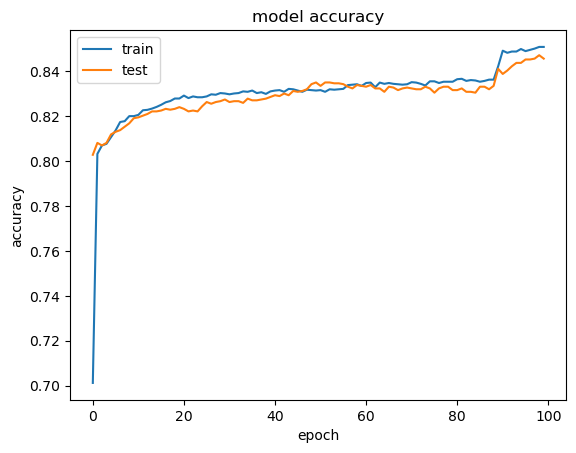

In [ ]:
# list all data in history

print(model_history.history.keys())
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

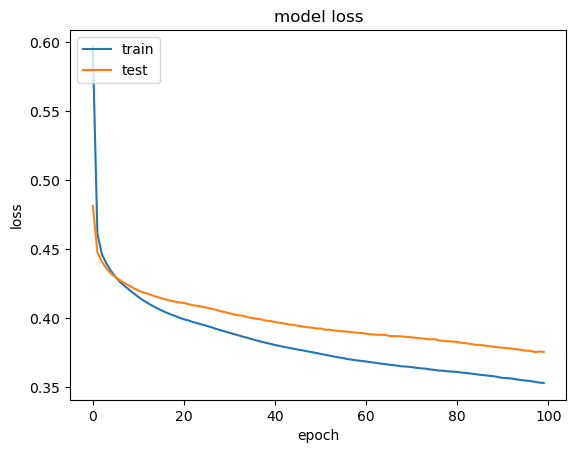

In [ ]:
# summarize history for loss
import matplotlib.pyplot as plt
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# Part 3 - Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)


# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
cm

array([[1523,   72],
       [ 227,  178]])

In [ ]:
score

0.8505

In [ ]:
y_pred

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])